# **Popular but Underperforming: Understanding Mismatch Between Course Ratings and Student Engagement**

Load, Inspect & Clean Coursera Dataset



In [4]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import zipfile
import os

# Unzip the uploaded archive
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/coursera_dataset')

# Load the extracted CSV file (update if actual file name is different)
csv_files = [f for f in os.listdir('/content/coursera_dataset') if f.endswith('.csv')]
file_path = f"/content/archive.zip"
df = pd.read_csv(file_path)

# Drop unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Function to convert string enrollments to numeric
def parse_enrollment(value):
    value = str(value).lower().strip()
    if 'k' in value:
        return float(value.replace('k', '')) * 1000
    elif 'm' in value:
        return float(value.replace('m', '')) * 1_000_000
    else:
        return pd.to_numeric(value, errors='coerce')

# Apply conversion
df['course_students_enrolled'] = df['course_students_enrolled'].apply(parse_enrollment)

# REMOVE courses with non-English characters in course_title
df = df[df['course_title'].apply(lambda x: isinstance(x, str) and x.isascii())]

# Remove rows with missing critical values (optional safety)
df.dropna(subset=['course_students_enrolled', 'course_rating'], inplace=True)

#  Cleaning Complete
print(" Dataset cleaned and loaded successfully.")

# Preview the first few rows
print("\n First 5 rows of the cleaned dataset:")
print(df.head())

# Check column types and summary
print("\n Data types and structure:")
print(df.dtypes)

print("\n Missing values in each column:")

 Dataset cleaned and loaded successfully.

 First 5 rows of the cleaned dataset:
                                        course_title  \
1  A Crash Course in Causality:  Inferring Causal...   
2                     A Crash Course in Data Science   
3                            A Law Student's Toolkit   
4                A Life of Happiness and Fulfillment   
5  ADHD: Everyday Strategies for Elementary Students   

          course_organization course_Certificate_type  course_rating  \
1  University of Pennsylvania                  COURSE            4.7   
2    Johns Hopkins University                  COURSE            4.5   
3             Yale University                  COURSE            4.7   
4   Indian School of Business                  COURSE            4.8   
5       University at Buffalo                  COURSE            4.7   

  course_difficulty  course_students_enrolled  
1      Intermediate                   17000.0  
2             Mixed                  130000.0  
3    

Distribution of Course Ratings

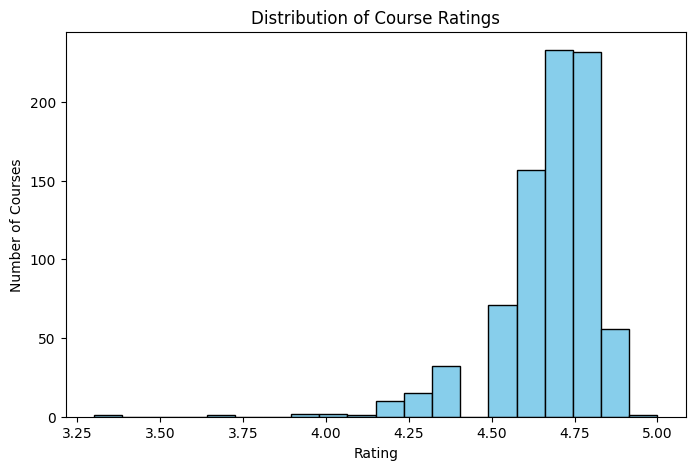

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df['course_rating'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Course Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Courses')
plt.grid(False)
plt.show()


Distribution of Students Enrolled

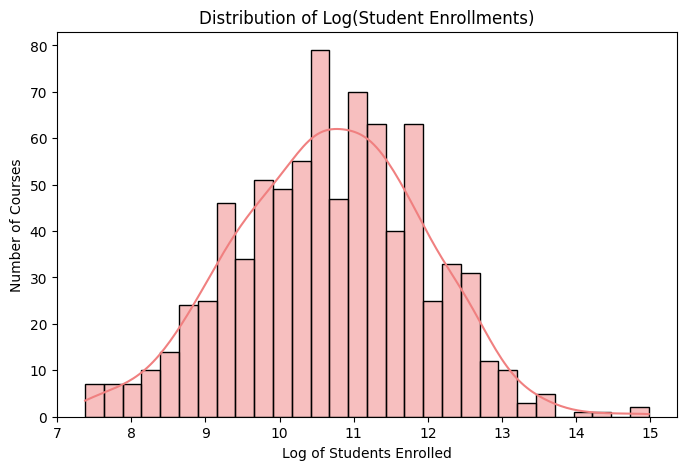

In [6]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df['course_students_enrolled']), bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Log(Student Enrollments)')
plt.xlabel('Log of Students Enrolled')
plt.ylabel('Number of Courses')
plt.grid(False)
plt.show()


Number of Courses by Difficulty Level

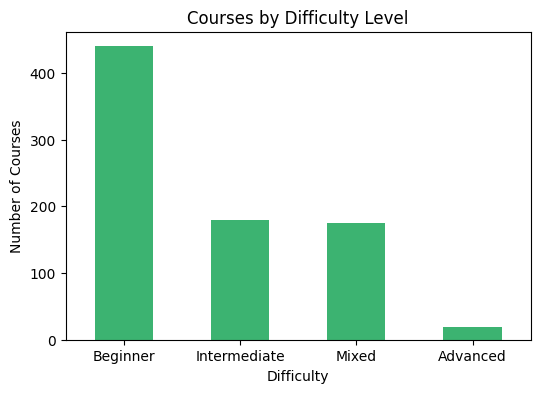

In [7]:
plt.figure(figsize=(6, 4))
df['course_difficulty'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Courses by Difficulty Level')
plt.xlabel('Difficulty')
plt.ylabel('Number of Courses')
plt.xticks(rotation=0)
plt.grid(False)
plt.show()


Find courses that are highly rated  but have low enrollment.

In [8]:
# Step 2: Identify mismatched courses

# Thresholds can be tuned — these are reasonable starting points
rating_threshold = 4.5
enrollment_threshold = df['course_students_enrolled'].median()

# Function to classify course into quadrants
def classify_course(row):
    if row['course_rating'] >= rating_threshold and row['course_students_enrolled'] < enrollment_threshold:
        return 'Popular but Underperforming'
    elif row['course_rating'] >= rating_threshold and row['course_students_enrolled'] >= enrollment_threshold:
        return 'Popular and Well-Enrolled'
    elif row['course_rating'] < rating_threshold and row['course_students_enrolled'] < enrollment_threshold:
        return 'Unpopular and Low Enrolled'
    else:
        return 'Underrated but Well-Enrolled'

# Apply classification
df['course_quadrant'] = df.apply(classify_course, axis=1)

# Count of each category
quadrant_counts = df['course_quadrant'].value_counts()
print(" Distribution of course types by quadrant:")
print(quadrant_counts)

# Preview mismatched courses
mismatched_courses = df[df['course_quadrant'] == 'Popular but Underperforming']
print("\n Sample of 'Popular but Underperforming' courses:")
print(mismatched_courses[['course_title', 'course_rating', 'course_students_enrolled', 'course_difficulty']].head())


 Distribution of course types by quadrant:
course_quadrant
Popular and Well-Enrolled       385
Popular but Underperforming     365
Unpopular and Low Enrolled       36
Underrated but Well-Enrolled     28
Name: count, dtype: int64

 Sample of 'Popular but Underperforming' courses:
                                         course_title  course_rating  \
1   A Crash Course in Causality:  Inferring Causal...            4.7   
5   ADHD: Everyday Strategies for Elementary Students            4.7   
7                            AI For Medical Treatment            4.8   
9                            AI for Medical Diagnosis            4.7   
10                           AI for Medical Prognosis            4.6   

    course_students_enrolled course_difficulty  
1                    17000.0      Intermediate  
5                    39000.0          Beginner  
7                     2400.0      Intermediate  
9                    12000.0      Intermediate  
10                    4000.0      Intermed

Course Types by Quadrant

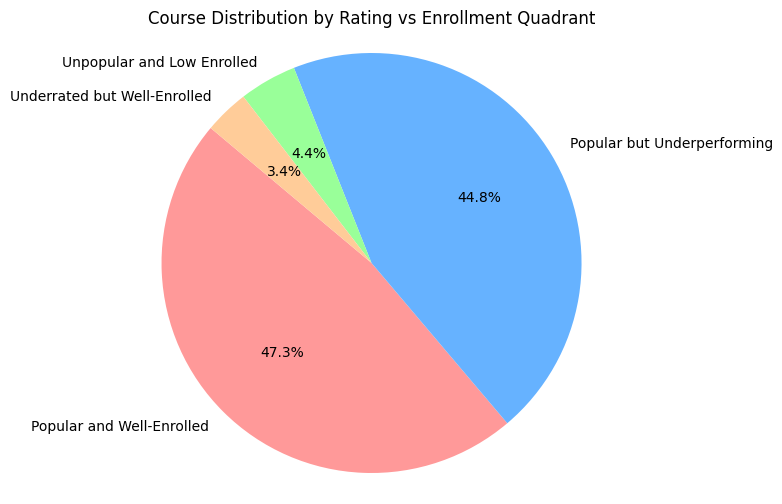

In [9]:
import matplotlib.pyplot as plt

# Count course types by quadrant
quadrant_counts = df['course_quadrant'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie(
    quadrant_counts,
    labels=quadrant_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
)
plt.title('Course Distribution by Rating vs Enrollment Quadrant')
plt.axis('equal')  # Equal aspect ratio ensures a perfect circle
plt.show()


Top 5 Mismatched Courses with Ratings & Enrollments



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter top 5 mismatched courses
top5 = mismatched_courses.sort_values(by='course_rating', ascending=False).head(5)

# Set up larger plot
plt.figure(figsize=(14, 7))

# Create color palette
palette = {'Beginner': '#66c2a5', 'Intermediate': '#fc8d62', 'Advanced': '#8da0cb', 'Mixed': '#e78ac3'}

# Plot barplot
sns.barplot(x='course_title', y='course_rating', hue='course_difficulty', data=top5,
            palette=palette, dodge=False)

# Add annotations for enrollment
for index, row in top5.iterrows():
    plt.text(index, row['course_rating'] + 0.05, f"{int(row['course_students_enrolled']):,} enrolled",
             color='black', ha='center', fontsize=9, rotation=0)

# Customize
plt.title('Top 5 “Popular but Underperforming” Courses\n(Rating vs Enrollment, colored by Difficulty)', fontsize=14)
plt.ylabel('Course Rating')
plt.xlabel('')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.ylim(0, 5.5)
plt.legend(title='Difficulty Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Manually adjust margins
plt.subplots_adjust(left=0.08, right=0.75, top=0.88, bottom=0.25)

plt.show()


Root Cause Exploration

/tmp/ipython-input-11-722099379.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mismatched_courses, x='course_difficulty', palette='Set2')


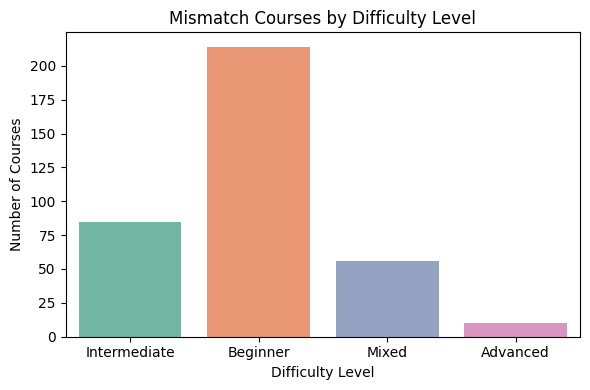

/tmp/ipython-input-11-722099379.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=mismatched_courses, x='course_Certificate_type', palette='Set3')


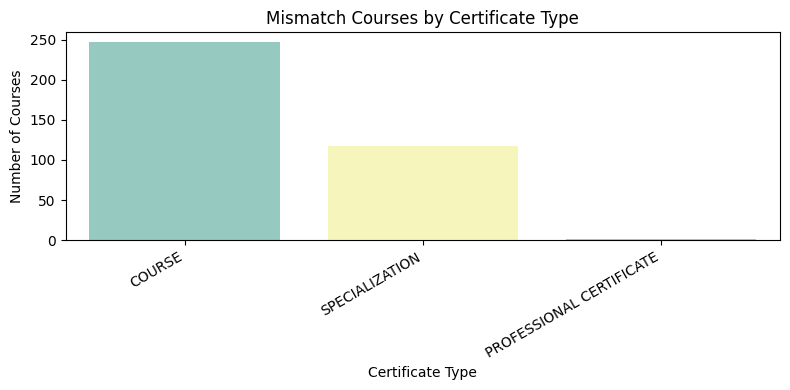

/tmp/ipython-input-11-722099379.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_orgs.values, y=top_orgs.index, palette='viridis')


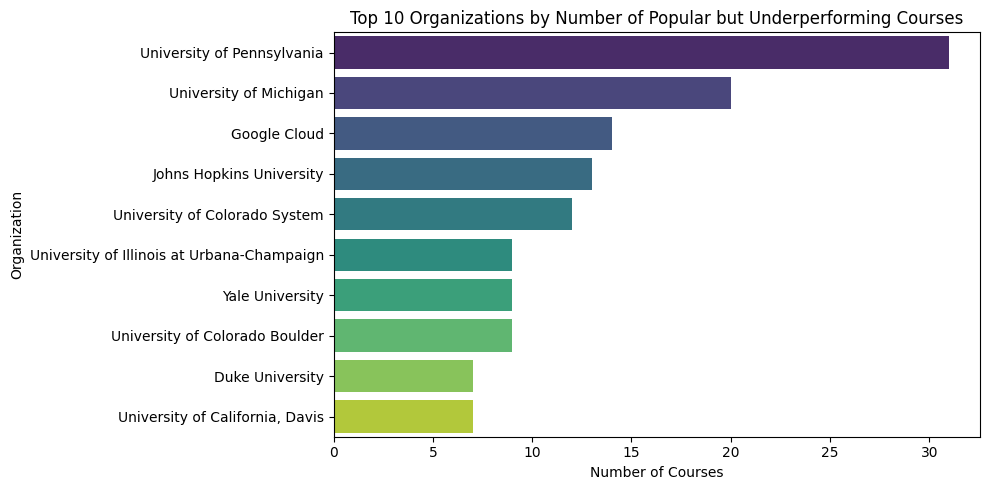

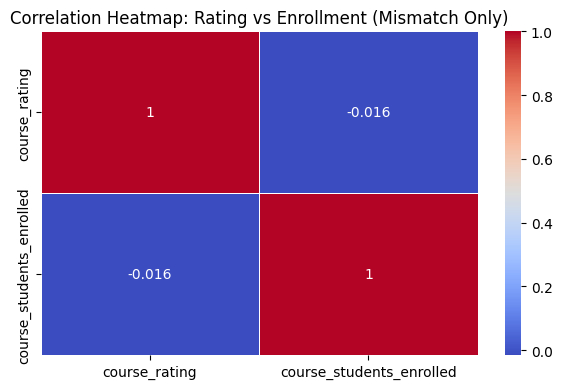

In [11]:


# Filter mismatched courses
mismatched_courses = df[df['course_quadrant'] == 'Popular but Underperforming']

# -----------------------------------------
# 1. Bar Chart: Distribution by Difficulty
# -----------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=mismatched_courses, x='course_difficulty', palette='Set2')
plt.title('Mismatch Courses by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Number of Courses')
plt.grid(False)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 2. Bar Chart: Distribution by Certificate Type
# -------------------------------------------------
plt.figure(figsize=(8, 4))
sns.countplot(data=mismatched_courses, x='course_Certificate_type', palette='Set3')
plt.title('Mismatch Courses by Certificate Type')
plt.xlabel('Certificate Type')
plt.ylabel('Number of Courses')
plt.xticks(rotation=30, ha='right')
plt.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Horizontal Bar Chart: Top 10 Organizations with Mismatches
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
top_orgs = mismatched_courses['course_organization'].value_counts().nlargest(10)
sns.barplot(x=top_orgs.values, y=top_orgs.index, palette='viridis')
plt.title('Top 10 Organizations by Number of Popular but Underperforming Courses')
plt.xlabel('Number of Courses')
plt.ylabel('Organization')
plt.tight_layout()
plt.show()

# ------------------------------------------------------
# 4. Correlation Heatmap: Ratings vs Enrollments
# ------------------------------------------------------
numerical_data = mismatched_courses[['course_rating', 'course_students_enrolled']]
plt.figure(figsize=(6, 4))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: Rating vs Enrollment (Mismatch Only)')
plt.tight_layout()
plt.show()




Cross-tab Table Only

In [12]:


# Filter 'Popular but Underperforming' courses
mismatched_courses = df[df['course_quadrant'] == 'Popular but Underperforming']

# Generate cross-tab
crosstab = pd.crosstab(
    mismatched_courses['course_difficulty'],
    mismatched_courses['course_Certificate_type'],
    margins=True,
    margins_name='Total'
)

# Display in styled table (optional formatting for presentation)
styled_table = crosstab.style.set_caption("📊 Difficulty vs Certificate Type (Mismatch Courses)") \
                              .set_table_styles([
                                  {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}
                              ]) \
                              .background_gradient(cmap="Blues", axis=None)

styled_table


course_Certificate_type,COURSE,PROFESSIONAL CERTIFICATE,SPECIALIZATION,Total
course_difficulty,,,,
Advanced,7,0,3,10
Beginner,133,1,80,214
Intermediate,51,0,34,85
Mixed,56,0,0,56
Total,247,1,117,365


Quadrant Map (Scatter Plot)

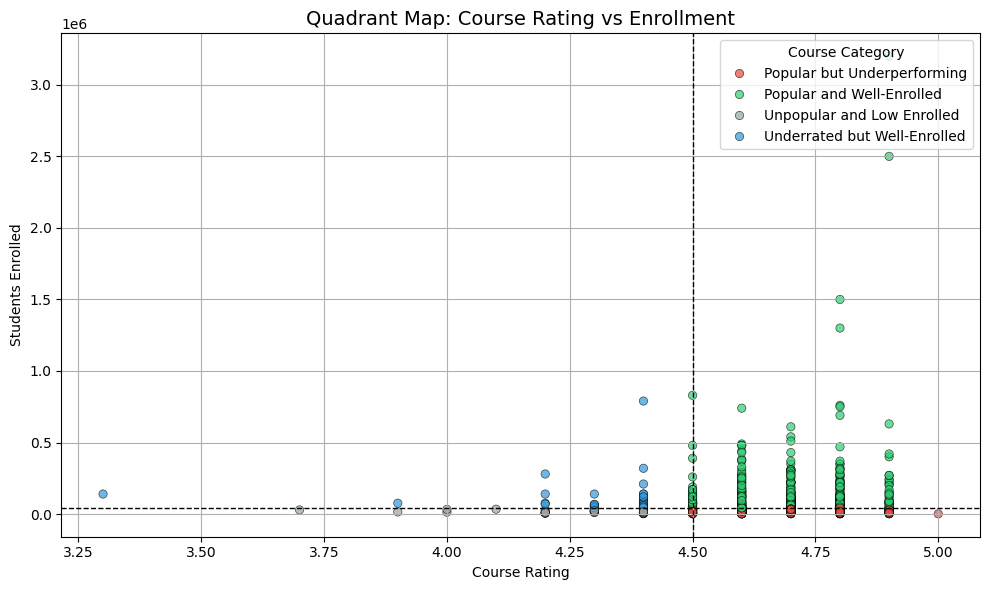

In [13]:


# Recalculate thresholds (in case you rerun separately)
rating_threshold = 4.5
enrollment_threshold = df['course_students_enrolled'].median()

# Set up plot
plt.figure(figsize=(10, 6))

# Plot all courses, colored by quadrant
sns.scatterplot(
    data=df,
    x='course_rating',
    y='course_students_enrolled',
    hue='course_quadrant',
    palette={
        'Popular but Underperforming': '#e74c3c',
        'Popular and Well-Enrolled': '#2ecc71',
        'Unpopular and Low Enrolled': '#95a5a6',
        'Underrated but Well-Enrolled': '#3498db'
    },
    alpha=0.7,
    edgecolor='black'
)

# Draw threshold lines
plt.axhline(enrollment_threshold, color='black', linestyle='--', linewidth=1)
plt.axvline(rating_threshold, color='black', linestyle='--', linewidth=1)

# Add labels and formatting
plt.title('Quadrant Map: Course Rating vs Enrollment', fontsize=14)
plt.xlabel('Course Rating')
plt.ylabel('Students Enrolled')
plt.legend(title='Course Category', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


underperforming courses by difficulty

/tmp/ipython-input-14-4013610086.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=difficulty_counts.index, y=difficulty_counts.values, palette='viridis')


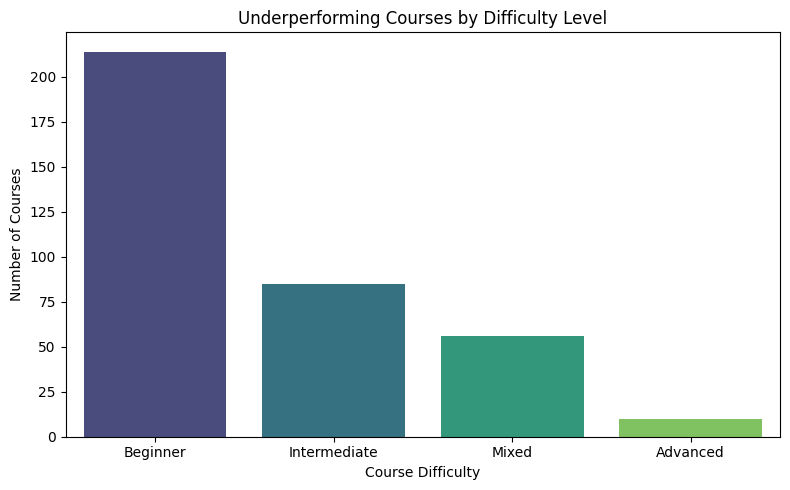

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter underperforming courses
underperforming = df[df['course_quadrant'] == 'Popular but Underperforming']

# Count of underperforming courses by difficulty
difficulty_counts = underperforming['course_difficulty'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=difficulty_counts.index, y=difficulty_counts.values, palette='viridis')
plt.title('Underperforming Courses by Difficulty Level')
plt.xlabel('Course Difficulty')
plt.ylabel('Number of Courses')
plt.tight_layout()
plt.savefig("bar_underperforming_difficulty.png")
plt.show()


Predicting Student Enrollments

📈 Predictive Modeling Results:
Mean Squared Error (MSE): 13633574627.50
R² Score: -0.122


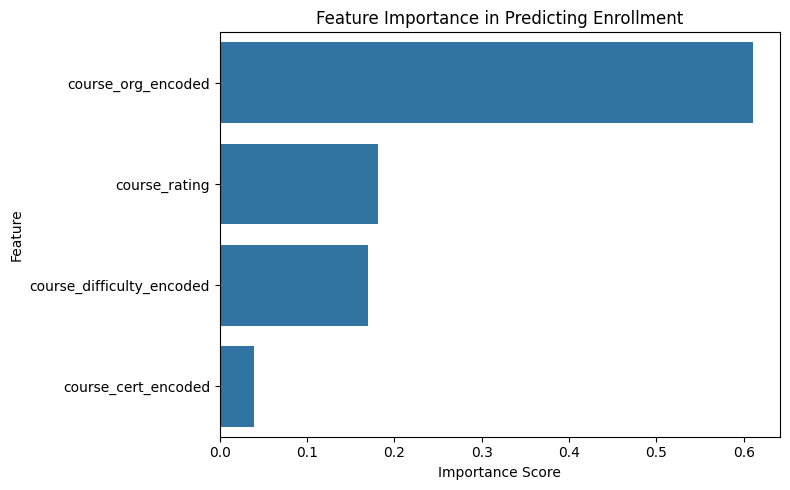

In [15]:
# Step 1: Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 2: Select features and target
df_model = df.copy()

# Drop rows with missing values (for modeling only)
df_model.dropna(subset=['course_rating', 'course_students_enrolled', 'course_difficulty', 'course_Certificate_type', 'course_organization'], inplace=True)

# Encode categorical columns
le_difficulty = LabelEncoder()
le_cert = LabelEncoder()
le_org = LabelEncoder()

df_model['course_difficulty_encoded'] = le_difficulty.fit_transform(df_model['course_difficulty'])
df_model['course_cert_encoded'] = le_cert.fit_transform(df_model['course_Certificate_type'])
df_model['course_org_encoded'] = le_org.fit_transform(df_model['course_organization'])

# Feature matrix (X) and target vector (y)
X = df_model[['course_rating', 'course_difficulty_encoded', 'course_cert_encoded', 'course_org_encoded']]
y = df_model['course_students_enrolled']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📈 Predictive Modeling Results:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.3f}")

# Step 6: Feature importance visualization
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=[features[i] for i in indices])
plt.title("Feature Importance in Predicting Enrollment")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Linear Regression

📊 Linear Regression Results:
Mean Squared Error (MSE): 12562082797.67
R² Score: -0.034

🔍 Linear Regression Feature Coefficients:
                     Feature    Coefficient
0              course_rating  115101.085157
1  course_difficulty_encoded   28467.440788
2        course_cert_encoded   14666.017481
3         course_org_encoded      74.875053


/tmp/ipython-input-16-4008756135.py:51: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


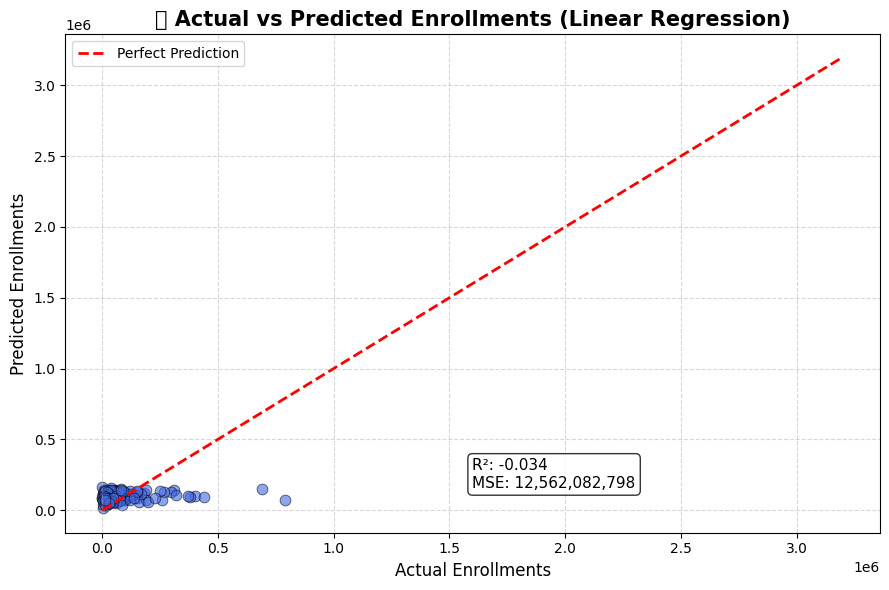

In [16]:
# Step 1: Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 2: Prepare features and target
X = df_model[['course_rating', 'course_difficulty_encoded', 'course_cert_encoded', 'course_org_encoded']]
y = df_model['course_students_enrolled']

# Step 3: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("📊 Linear Regression Results:")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.3f}")

# Step 6: Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
print("\n🔍 Linear Regression Feature Coefficients:")
print(coefficients)

# Step 7: Enhanced Plot: Actual vs Predicted
plt.figure(figsize=(9, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, color='royalblue', alpha=0.6, s=60, edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', label='Perfect Prediction', linewidth=2)

# Annotations
plt.title("📈 Actual vs Predicted Enrollments (Linear Regression)", fontsize=15, weight='bold')
plt.xlabel("Actual Enrollments", fontsize=12)
plt.ylabel("Predicted Enrollments", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.text(y.max()*0.5, y.max()*0.05, f"R²: {r2_lr:.3f}\nMSE: {mse_lr:,.0f}",
         fontsize=11, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.show()


Random Forest Output (After Feature Engineering):

In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# Make a clean copy
df_fe = df.copy()

# Step 1: Drop missing values first to avoid mismatches
df_fe.dropna(subset=['course_students_enrolled', 'course_rating', 'course_difficulty',
                     'course_organization', 'course_Certificate_type'], inplace=True)

# Step 2: One-hot encode categorical columns
categorical_cols = ['course_organization', 'course_Certificate_type', 'course_difficulty']
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df_fe[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=df_fe.index)

# Step 3: Combine encoded features with numerical ones
df_model = pd.concat([df_fe[['course_rating']], encoded_df], axis=1)

# Step 4: Define target
y = df_fe['course_students_enrolled']

# Step 5: Train/test split
X_train, X_test, y_train, y_test = train_test_split(df_model, y, test_size=0.2, random_state=42)

# Step 6: Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 7: Predict
y_pred = model.predict(X_test)

# Step 8: Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ R-squared: {r2:.3f}")
print(f"📉 RMSE: {rmse:.2f}")


✅ R-squared: -0.145
📉 RMSE: 117951.92


/tmp/ipython-input-21-661996335.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_d')


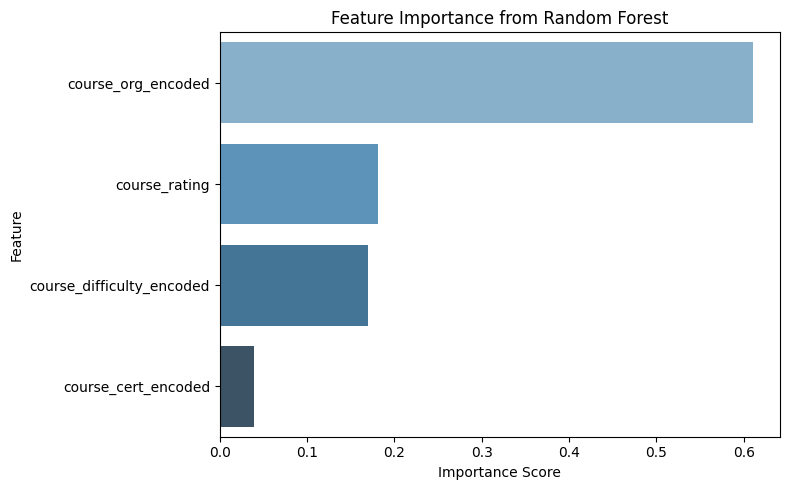

In [21]:
# Step 1: Import libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 2: Encode categorical variables (if not already done)
df_encoded = df.copy()
df_encoded['course_difficulty_encoded'] = df_encoded['course_difficulty'].astype('category').cat.codes
df_encoded['course_cert_encoded'] = df_encoded['course_Certificate_type'].astype('category').cat.codes
df_encoded['course_org_encoded'] = df_encoded['course_organization'].astype('category').cat.codes

# Step 3: Prepare features and target
features = ['course_rating', 'course_difficulty_encoded', 'course_cert_encoded', 'course_org_encoded']
X = df_encoded[features]
y = df_encoded['course_students_enrolled']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Step 6: Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Step 7: Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='Blues_d')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Conclusion

While we modeled course enrollment using available features like rating, difficulty, certification, and organization, our models (Linear Regression and Random Forest) showed poor predictive performance. This indicates the missing influence of behavioural and external variables not captured in the dataset. To improve, we would engineer additional features and incorporate external data sources.

Add external features like Course duration, Time since launch, Instructor name, Promo activity, Reviews sentiment. We will be able to make more accurate predictions